# 03: Fixing the probabilities, with scikit-learn's calibration example

Notebook 02 found that the paper's logistic regression *ranks* customers as well
as Yeh & Lien (2009) report, but its *probabilities* are off in an S shape
(Figure 2.5). This notebook takes a published, runnable example on exactly that
problem. We run it as published, then adapt it to the Taiwan data to see
whether the probabilities can be fixed.

**The resource.** *Probability Calibration curves*, an example in the
scikit-learn documentation, version 1.9.1:
https://scikit-learn.org/stable/auto_examples/calibration/plot_calibration_curve.html
(source `examples/calibration/plot_calibration_curve.py`; © the scikit-learn
developers, BSD-3-Clause licence, which allows reuse with this notice). The
example cites Niculescu-Mizil & Caruana (2005).

**Why this one.** It compares logistic regression with **Gaussian naive
Bayes**, one of the six methods in Yeh & Lien (2009). It fixes probabilities
with `CalibratedClassifierCV` and scores them with the Brier score and log loss,
so it lets us both fix our logistic regression and test a second method from
the paper.

* **Part A:** the example's naive Bayes half, run unchanged on its synthetic data
* **Part B:** the same method on the Taiwan data, with the changes we had to make
* **Part C:** our naive Bayes against the paper's

Run `01-Introduction.ipynb` first; Part B loads `data/processed/taiwan-clean.csv`.

## Part A: the example, as published

The code cells in this part are copied **unchanged** from the first half of the
example. Its second half repeats the method with a linear support vector
classifier, which isn't one of the paper's methods, so we left it out.

**Data.** A synthetic dataset of 100,000 rows and 20 columns. Only 2 columns
carry signal, 10 are mixtures of those 2, and 8 are noise. The example trains on
1,000 rows and tests on the other 99,000.

In [9]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_samples=100_000, n_features=20, n_informative=2, n_redundant=10, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.99, random_state=42
)

**Models.** Logistic regression as a baseline, which the example says is usually
well calibrated already, because it is fitted by minimising log loss. Then naive
Bayes, uncalibrated and with the two fixes `CalibratedClassifierCV` offers:

* **sigmoid** (Platt scaling; Platt, 1999): fit a logistic curve from the
  model's score to the outcome;
* **isotonic** (Zadrozny & Elkan, 2002): fit any non-decreasing step function
  from the score to the outcome.

`cv=2` fits each fix by cross-validation inside the training data.

In [10]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

lr = LogisticRegression(C=1.0)
gnb = GaussianNB()
gnb_isotonic = CalibratedClassifierCV(gnb, cv=2, method="isotonic")
gnb_sigmoid = CalibratedClassifierCV(gnb, cv=2, method="sigmoid")

clf_list = [
    (lr, "Logistic"),
    (gnb, "Naive Bayes"),
    (gnb_isotonic, "Naive Bayes + Isotonic"),
    (gnb_sigmoid, "Naive Bayes + Sigmoid"),
]

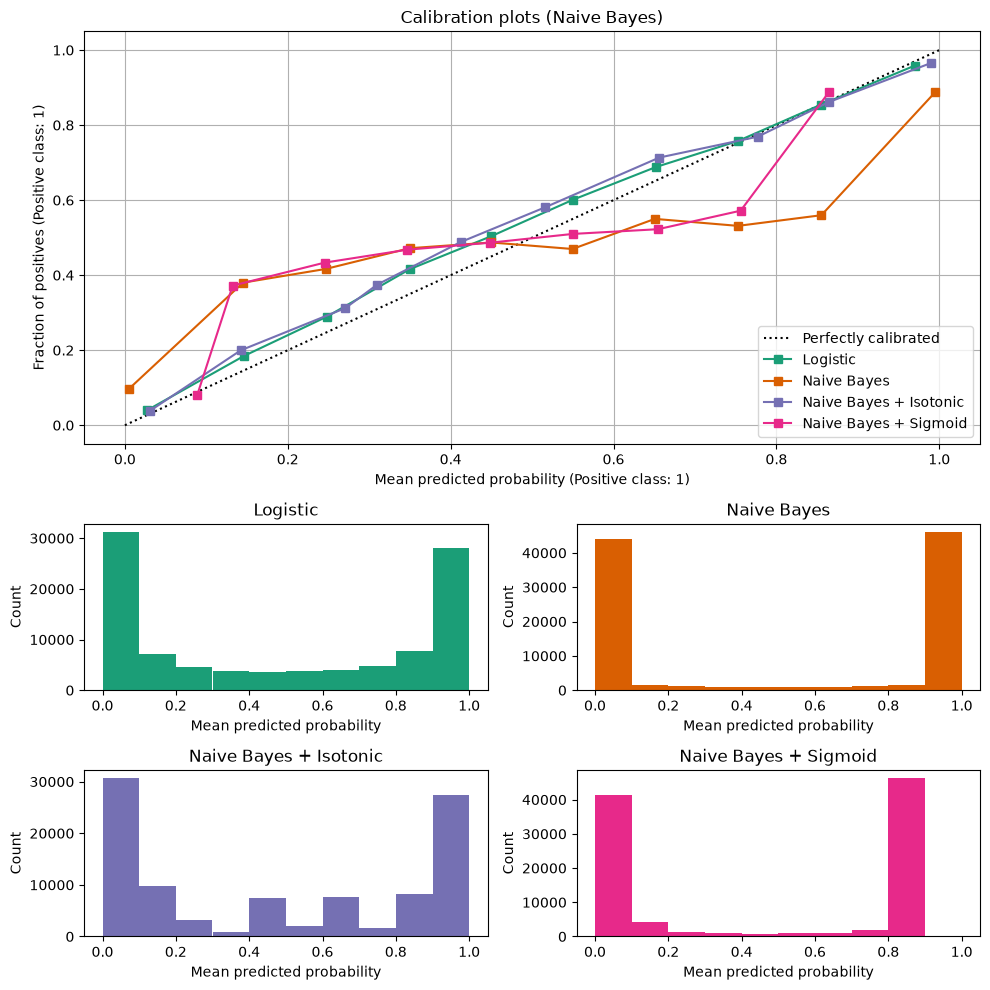

In [11]:
fig = plt.figure(figsize=(10, 10))
gs = GridSpec(4, 2)
colors = plt.get_cmap("Dark2")

ax_calibration_curve = fig.add_subplot(gs[:2, :2])
calibration_displays = {}
for i, (clf, name) in enumerate(clf_list):
    clf.fit(X_train, y_train)
    display = CalibrationDisplay.from_estimator(
        clf,
        X_test,
        y_test,
        n_bins=10,
        name=name,
        ax=ax_calibration_curve,
        color=colors(i),
    )
    calibration_displays[name] = display

ax_calibration_curve.grid()
ax_calibration_curve.set_title("Calibration plots (Naive Bayes)")

# Add histogram
grid_positions = [(2, 0), (2, 1), (3, 0), (3, 1)]
for i, (_, name) in enumerate(clf_list):
    row, col = grid_positions[i]
    ax = fig.add_subplot(gs[row, col])

    ax.hist(
        calibration_displays[name].y_prob,
        range=(0, 1),
        bins=10,
        label=name,
        color=colors(i),
    )
    ax.set(title=name, xlabel="Mean predicted probability", ylabel="Count")

plt.tight_layout()
plt.show()

**Figure 3.1** (the example's own plot, unchanged). Top: calibration curves,
each model's average prediction against the actual share of positives in 10
bins; the dotted diagonal is perfect. Bottom: how the predictions are spread.

The example explains that uncalibrated naive Bayes is *over-confident*. The 10
redundant columns break its assumption that columns are independent, so it
counts the same evidence several times and pushes probabilities towards 0 and 1.
That gives a "transposed sigmoid" curve. Isotonic calibration fixes it almost
completely, and sigmoid helps only a little.

**The metrics.** Brier score and log loss judge the probabilities, ROC AUC judges
the ranking, and precision, recall and F1 judge the yes/no predictions at
threshold 0.5.

In [12]:
from collections import defaultdict

import pandas as pd

from sklearn.metrics import (
    brier_score_loss,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)

scores = defaultdict(list)
for i, (clf, name) in enumerate(clf_list):
    clf.fit(X_train, y_train)
    y_prob = clf.predict_proba(X_test)
    y_pred = clf.predict(X_test)
    scores["Classifier"].append(name)

    for metric in [brier_score_loss, log_loss, roc_auc_score]:
        score_name = metric.__name__.replace("_", " ").replace("score", "").capitalize()
        scores[score_name].append(metric(y_test, y_prob[:, 1]))

    for metric in [precision_score, recall_score, f1_score]:
        score_name = metric.__name__.replace("_", " ").replace("score", "").capitalize()
        scores[score_name].append(metric(y_test, y_pred))

    score_df = pd.DataFrame(scores).set_index("Classifier")
    score_df.round(decimals=3)

score_df

,Brier loss,Log loss,Roc auc,Precision,Recall,F1
Classifier,,,,,,
Logistic,0.098932,0.323200,0.937443,0.871965,0.851348,0.861533
Naive Bayes,0.117608,0.782755,0.940373,0.857400,0.875941,0.866571
Naive Bayes + Isotonic,0.098332,0.370738,0.938613,0.883065,0.836224,0.859007
Naive Bayes + Sigmoid,0.108880,0.368896,0.940201,0.861106,0.871277,0.866161


**What the example concludes.** Calibration improves the Brier score and log
loss but barely changes precision, recall and F1. ROC AUC "should not change at
all because calibration is a monotonic transformation". Sigmoid calibration can
fix a sigmoid-shaped curve but **not** naive Bayes's transposed sigmoid; isotonic
can fix both, but may need more data.

**It ran as published:** every number in the table matches the documentation
page to six decimal places.

## Part B: the same method on the Taiwan data

What we changed, and why:

1. **The data:** the cleaned Taiwan file, with the **same three-way split as
   notebook 02** (same seeds), so the results line up.
2. **The logistic regression is the paper's** (no penalty, `C=np.inf`, scaled),
   not the example's `C=1.0`. Notebook 02 showed this makes no practical
   difference.
3. **Calibrate on the calibration set, not by cross-validation.** The example's
   `cv=2` refits the model inside its training data. We already set aside a
   calibration set for this job. So each model is fitted on **train** and frozen
   (`FrozenEstimator`, so `CalibratedClassifierCV` can't refit it), and only the
   correction is fitted, on the **calibration** set. Everything is scored on the
   **test** set.
4. **Calibration curves use 10 equal-size groups** (`strategy="quantile"`), as in
   Figure 2.5, not the example's 10 equal-width bins. Most customers have p
   between 0.1 and 0.3, so equal-width bins would leave most bins nearly empty.
5. **Our own colours and layout.** Each line also has its own marker, so the plot
   doesn't rely on colour alone.

In [13]:
from pathlib import Path
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
from sklearn.frozen import FrozenEstimator

ROOT = Path.cwd().parent            # notebooks run from report/
taiwan = pd.read_csv(ROOT / "data" / "processed" / "taiwan-clean.csv", index_col="ID")
Y = "default payment next month"
BLUE, ORANGE, GREY, GREEN = "#2a78d6", "#eb6834", "#8a8984", "#1a9e77"

# Same split as notebook 02: 60% train, 20% calibration, 20% test. (Replaces Part A's X and y.)
X = taiwan.drop(columns=Y)
y = taiwan[Y]
X_rest, X_test, y_rest, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=0)
X_train, X_cal, y_train, y_cal = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest, random_state=0)

# 1. Fit the two base models on TRAIN.
logistic = make_pipeline(StandardScaler(), LogisticRegression(C=np.inf, max_iter=5000))
naive_bayes = GaussianNB()
logistic.fit(X_train, y_train)
naive_bayes.fit(X_train, y_train)

# 2. Freeze each one and fit only the correction on the CALIBRATION set.
models = {}
for base, name in [(logistic, "Logistic"), (naive_bayes, "Naive Bayes")]:
    models[name] = base
    for method in ["isotonic", "sigmoid"]:
        fixed = CalibratedClassifierCV(FrozenEstimator(base), method=method)
        models[f"{name} + {method.capitalize()}"] = fixed.fit(X_cal, y_cal)

# 3. Predicted probabilities on the TEST set, for every model.
p_test = {name: m.predict_proba(X_test)[:, 1] for name, m in models.items()}
list(models)

['Logistic',
 'Logistic + Isotonic',
 'Logistic + Sigmoid',
 'Naive Bayes',
 'Naive Bayes + Isotonic',
 'Naive Bayes + Sigmoid']

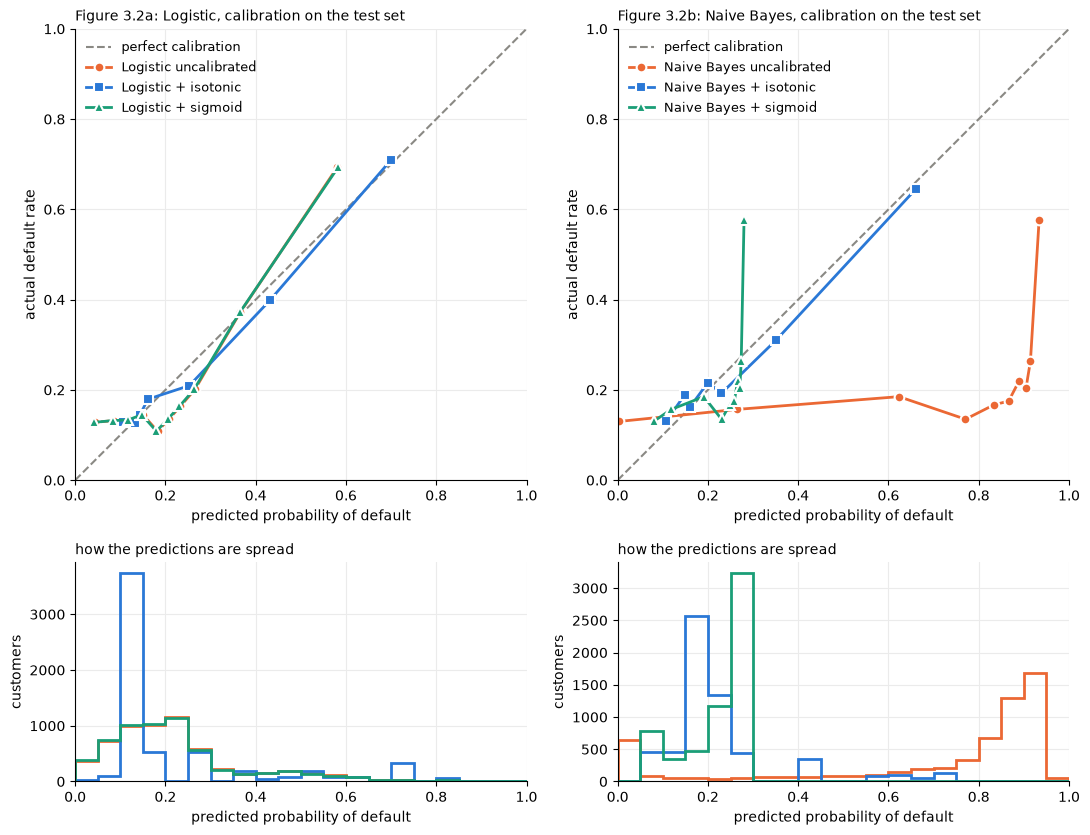

In [14]:
STYLE = {"":            (ORANGE, "o", "uncalibrated"),
         " + Isotonic": (BLUE,   "s", "+ isotonic"),
         " + Sigmoid":  (GREEN,  "^", "+ sigmoid")}

fig, axes = plt.subplots(2, 2, figsize=(11, 8.5), gridspec_kw={"height_ratios": [2.2, 1]})
for col, base in enumerate(["Logistic", "Naive Bayes"]):
    ax, hx = axes[0, col], axes[1, col]
    ax.plot([0, 1], [0, 1], color=GREY, linestyle="--", linewidth=1.5, label="perfect calibration")
    for suffix, (colour, marker, label) in STYLE.items():
        p = p_test[base + suffix]
        frac, mean_p = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
        ax.plot(mean_p, frac, marker=marker, color=colour, linewidth=2, markersize=7,
                markeredgecolor="white", markeredgewidth=1.5, label=f"{base} {label}")
        hx.hist(p, bins=20, range=(0, 1), histtype="step", linewidth=2, color=colour)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
    ax.set_title(f"Figure 3.2{'ab'[col]}: {base}, calibration on the test set", loc="left", fontsize=10)
    ax.set_xlabel("predicted probability of default")
    ax.set_ylabel("actual default rate")
    ax.legend(frameon=False, loc="upper left", fontsize=9)
    hx.set_xlim(0, 1)
    hx.set_xlabel("predicted probability of default")
    hx.set_ylabel("customers")
    hx.set_title("how the predictions are spread", loc="left", fontsize=10)
    for a in (ax, hx):
        a.spines[["top", "right"]].set_visible(False)
        a.grid(color="0.92"); a.set_axisbelow(True)
plt.tight_layout()
plt.show()

**Figure 3.2.** Top: each model's 10 groups, average prediction against actual
default rate, on the test set; on the dashed line is perfect. Bottom: how many
test customers get each predicted probability. Isotonic curves can show fewer
than 10 points, because isotonic maps customers onto a few dozen distinct
values, and groups that share a value merge.

Below is the example's metric table on the Taiwan test set, plus two columns of
ours: the share of customers flagged at 0.5, and the paper's error rate. As a
yardstick, the Brier score of predicting 22% for everyone is printed first.

In [15]:
rows = {}
for name, m in models.items():
    p = p_test[name]
    flag = m.predict(X_test)                      # yes/no at threshold 0.5, as in the example
    rows[name] = {
        "Brier": brier_score_loss(y_test, p),
        "Log loss": log_loss(y_test, p),
        "Roc auc": roc_auc_score(y_test, p),
        # zero_division=0: a model that flags nobody has no precision; report 0 instead of an error.
        "Precision": precision_score(y_test, flag, zero_division=0),
        "Recall": recall_score(y_test, flag),
        "F1": f1_score(y_test, flag, zero_division=0),
        "share flagged": flag.mean(),
        "error rate": np.mean(flag != y_test),
    }
results = pd.DataFrame(rows).T
print(f"Brier score of predicting {y_train.mean():.1%} for everyone: "
      f"{brier_score_loss(y_test, np.full(len(y_test), y_train.mean())):.3f}")
results.round(3)

Brier score of predicting 22.1% for everyone: 0.172


,Brier,Log loss,Roc auc,Precision,Recall,F1,share flagged,error rate
Logistic,0.146,0.470,0.712,0.724,0.246,0.367,0.075,0.188
Logistic + Isotonic,0.141,0.474,0.715,0.678,0.361,0.471,0.118,0.179
Logistic + Sigmoid,0.146,0.471,0.712,0.726,0.247,0.369,0.075,0.187
Naive Bayes,0.462,1.515,0.652,0.240,0.864,0.375,0.796,0.636
Naive Bayes + Isotonic,0.156,0.490,0.650,0.646,0.192,0.296,0.066,0.202
Naive Bayes + Sigmoid,0.169,0.520,0.652,0.000,0.000,0.000,0.000,0.221


### Logistic regression: isotonic calibration fixes the S shape

* **The probabilities are fixed.** The 10 groups now lie near the diagonal
  (Figure 3.2a), and the Brier score improves from 0.146 to **0.141**. Part C
  shows the paper's straight-line summary moving to slope 0.98, intercept 0.00,
  close to the ideal 1 and 0. Both the correction and the check use data the
  model never trained on.
* **Log loss gets very slightly *worse*** (0.470 → 0.474). Isotonic is a step
  function fitted to 6,000 customers, so its extreme steps rest on few customers,
  and log loss punishes confident mistakes hard. The two proper scoring rules can
  disagree, and choosing between them is a judgement.
* **Sigmoid calibration does almost nothing** (Brier 0.146 both ways; the curves
  overlap). It fits a logistic curve to the model's score, and a logistic
  regression's output is already a logistic curve of a linear score. So it can
  only stretch the curve, not bend it into the S-shaped correction we need. This
  fits the example's summary: sigmoid can only fix one particular shape.
* **ROC AUC moved slightly** (0.712 → 0.715), although the example says it
  shouldn't. Isotonic is *non-decreasing*, not strictly increasing: it maps
  6,000 customers onto a few dozen values, creating ties, and AUC counts ties as
  half. The principle holds, but not to three decimal places.
* **Calibration changes what 0.5 means.** After isotonic, 11.8% of customers are
  above 0.5 (7.5% before), recall at 0.5 rises from 0.25 to 0.36, and the error
  rate falls to **0.179**, just below the paper's 0.18. The ranking hasn't
  changed, only the scale of the scores. As in notebook 02, step 4: a threshold
  is a choice, not part of the model.

### Naive Bayes: very badly calibrated, and only partly fixable

* **Gaussian naive Bayes gives most customers a probability between 0.8 and
  0.95** (Figure 3.2b, bottom), although 22% default. It flags 80% of customers
  at 0.5, and its Brier score (0.462) is **worse than predicting 22% for
  everyone** (0.172). This is the over-confidence the example describes, with
  the same likely cause. Naive Bayes treats the columns as independent, but the
  six bill columns overlap heavily (Figure 2.1), so the same evidence is counted
  several times. The money columns are also very skewed, far from the bell
  curves Gaussian naive Bayes assumes.
* **Sigmoid can't fix it.** Its largest prediction is about 0.30, so at 0.5 it
  flags nobody (precision 0 by convention, error rate 0.221 = the default rate).
  This is the example's warning about naive Bayes's transposed sigmoid, now seen
  on real data.
* **Isotonic rescues the probabilities but not the ranking.** Brier falls to
  0.156, but AUC stays at 0.65, below logistic regression's 0.71, because
  calibration doesn't reorder customers. Calibrated naive Bayes is still worse
  than logistic regression on every measure here.

## Part C: naive Bayes against the paper

Yeh & Lien (2009) report naive Bayes too. Their Table 1 gives an error rate of
0.21 and an area ratio of **0.53** on validation data, *better* than their
logistic regression's 0.44. Their Table 2 gives the Sorting Smoothing Method
line real = A + B × predicted with **B = 0.502, A = 0.0901, R² = 0.899**.

We compute the same for our models. The area ratio is 2 × AUC − 1 (notebook 02,
step 2), and `ssm_line` is the function from notebook 02, step 5.

In [16]:
def ssm_line(y_true, p, n=50):
    """Yeh & Lien's Sorting Smoothing Method and straight-line fit (as in notebook 02, step 5)."""
    order = np.argsort(p, kind="stable")
    p_sorted, y_sorted = p[order], np.asarray(y_true)[order]
    window = 2 * n + 1
    real = np.convolve(y_sorted, np.ones(window) / window, mode="valid")
    pred = p_sorted[n:len(p_sorted) - n]
    B, A = np.polyfit(pred, real, 1)
    return {"slope B": B, "intercept A": A, "R²": np.corrcoef(pred, real)[0, 1] ** 2}

paper = {
    "Logistic (Yeh & Lien)":    {"error rate": 0.18, "area ratio": 0.44, "slope B": 1.233, "intercept A": -0.0523, "R²": 0.794},
    "Naive Bayes (Yeh & Lien)": {"error rate": 0.21, "area ratio": 0.53, "slope B": 0.502, "intercept A": 0.0901,  "R²": 0.899},
}
ours = {f"{name} (ours)": {"error rate": results.loc[name, "error rate"],
                           "area ratio": 2 * results.loc[name, "Roc auc"] - 1,
                           **ssm_line(y_test, p_test[name])}
        for name in ["Logistic", "Logistic + Isotonic", "Naive Bayes", "Naive Bayes + Isotonic"]}
pd.DataFrame({**paper, **ours}).T.round(3)

,error rate,area ratio,slope B,intercept A,R²
Logistic (Yeh & Lien),0.180,0.440,1.233,-0.052,0.794
Naive Bayes (Yeh & Lien),0.210,0.530,0.502,0.090,0.899
Logistic (ours),0.188,0.425,1.119,-0.028,0.808
Logistic + Isotonic (ours),0.179,0.430,0.979,0.004,0.938
Naive Bayes (ours),0.636,0.303,0.170,0.098,0.167
Naive Bayes + Isotonic (ours),0.202,0.300,0.883,0.025,0.904


**We could not reproduce the paper's naive Bayes.** This is a dead end, but an
informative one.

* The paper's naive Bayes has an area ratio of **0.53**, better than its
  logistic regression. Ours has **0.30**, much worse. Its line is B = 0.502,
  R² = 0.899; ours (uncalibrated) is 0.17 and 0.17. Our logistic regression
  matches the paper closely, so the data and split aren't the problem. The method
  is.
* The paper says only "naive Bayesian classifier", and doesn't say how the money
  columns were handled. Naive Bayes can treat them as bell curves (as
  scikit-learn's `GaussianNB` does) or cut them into bands first, and the two can
  behave very differently on skewed columns. We can't tell which the paper did.
* **So the paper's ranking of methods doesn't carry over to the scikit-learn
  version of the same method.** A method's name isn't enough to reproduce a
  result: the implementation details matter, and a paper without code doesn't
  give them. That is an argument for publishing code, which bears on the brief's
  question about sharing code on GitHub.

> **Link to MATH30028** (Maullin, 2026).
> * Sigmoid (Platt) calibration is itself a logistic regression with the
>   model's score as the only covariate (§2.3.8). Applied to a logistic
>   regression, it can only rescale, which is why it barely changed ours.
> * Isotonic calibration is piecewise-constant ("histogram") regression
>   (§2.3.3) with data-chosen knots and non-decreasing steps, hence its few
>   dozen distinct values.
> * Naive Bayes is *generative* and logistic regression *discriminative*
>   (§3.1.5). Gaussian naive Bayes assumes each column is Gaussian within each
>   class, and that columns are conditionally independent given the class
>   (§3.3.4, Remark 12). The skewed money columns break the first assumption and
>   the near-duplicate bill columns break the second.
> * A possible explanation for the paper's result: naive Bayes is often run with
>   *categorical* distributions on banded columns, with Laplace smoothing for
>   empty bands (§3.3.4, Lemma 28). Banding would remove the skew problem. This
>   is our hypothesis; the paper doesn't say.

## Summary

| | Brier (test) | AUC | Verdict |
|---|---|---|---|
| Logistic, uncalibrated | 0.146 | 0.712 | ranks well, S-shaped probabilities (notebook 02) |
| Logistic + isotonic | **0.141** | 0.715 | **probabilities fixed**; ranking unchanged |
| Logistic + sigmoid | 0.146 | 0.712 | no effect: can't bend a logistic curve |
| Naive Bayes, uncalibrated | 0.462 | 0.652 | worse than predicting 22% for everyone |
| Naive Bayes + isotonic | 0.156 | 0.650 | probabilities rescued, ranking still poor |
| *Predict 22% for everyone* | *0.172* | *0.5* | *yardstick* |

**What the resource gave us:** a ready-made, correct method for fixing
probabilities, and a warning (sigmoid can't fix every shape) that turned out to
apply to real data as well as to its synthetic example.

**What we had to change:** the example calibrates by cross-validation and bins
by equal width. On credit data with a held-out calibration set and predictions
bunched between 0.1 and 0.3, a frozen model and equal-size groups were the
better fit.

**What it showed about the paper:** naive Bayes, which the paper ranks above
logistic regression, comes out well below it in scikit-learn's version. Without
the paper's code, we can't say why.

## References

* Niculescu-Mizil, A. & Caruana, R. (2005). Predicting good probabilities with
  supervised learning. *Proceedings of the 22nd International Conference on
  Machine Learning*, 625–632. https://doi.org/10.1145/1102351.1102430
* Maullin, T. (2026). *MATH30028 Statistical Machine Learning, Part I*,
  lecture notes. University of Bristol.
* Pedregosa, F. et al. (2011). Scikit-learn: machine learning in Python.
  *Journal of Machine Learning Research* 12, 2825–2830.
* Platt, J. (1999). Probabilistic outputs for support vector machines and
  comparisons to regularized likelihood methods. In *Advances in Large Margin
  Classifiers*, 61–74. MIT Press.
* scikit-learn developers (n.d.). *Probability Calibration curves* [code
  example], scikit-learn 1.9.1 documentation. Accessed 3 October 2026.
  https://scikit-learn.org/stable/auto_examples/calibration/plot_calibration_curve.html
* Yeh, I-C. & Lien, C-H. (2009). The comparisons of data mining techniques for
  the predictive accuracy of probability of default of credit card clients.
  *Expert Systems with Applications* 36(2), 2473–2480.
  https://doi.org/10.1016/j.eswa.2007.12.020
* Zadrozny, B. & Elkan, C. (2002). Transforming classifier scores into accurate
  multiclass probability estimates. *Proceedings of the 8th ACM SIGKDD
  International Conference on Knowledge Discovery and Data Mining*, 694–699.
  https://doi.org/10.1145/775047.775151

Full working: [`Oscar/08-calibration.ipynb`](../Oscar/08-calibration.ipynb).